Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7fea32403740>
  [1] SingleMuonAnalysis -> Analysis builder=<function run_analysis at 0x7fea324039c0>
  [2] PlottingMuonAnalysis -> Plotting builder=analysis:plot_results
Edges:
  Fileset -> SingleMuonAnalysis
  SingleMuonAnalysis -> PlottingMuonAnalysis
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7fea32403740> and user parameters {'to_print': '\nTEST:\npass parameter to builder...\nSUCCESS!\n'}

kwargs: {'to_print': '\nTEST:\npass parameter to builder...\nSUCCESS!\n'}

TEST:
pass parameter to builder...
SUCCESS!

  -> materialized at .cache/Fileset/674994588d3ff4f494114d67701b0a859cfda45f939e593eb2b86110fd336cfd
Executing step 'SingleMuonAnalysis' of type 'Analysis' with the user code <function run_analysis at 0x7fea324039c0> and user parameters None
Connecting to Dask scheduler...
Uploaded analysis.py to workers
Installing on workers: ['git+https://github.com/hooloobo

Output()

Output()

Output()

Successfully processed!
------------------------------------
Processing fileset_chunk_1.json


...

Output()

Output()

Successfully processed!
------------------------------------
Processing fileset_chunk_6.json


Output()

Successfully processed!
  -> materialized at .cache/Analysis/4e67893fd6de421e74f3a8d82c95e02945bebf57118a9415ac5579e1d5e516b1
Executing step 'PlottingMuonAnalysis' of type 'Plotting' with the user code analysis:plot_results and user parameters None
Result keys: ['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result']
n_chunks_ok: 7 / 7
  -> materialized at .cache/Plotting/fbc5f4411fb88019748721005bb34b1cafa55f35aa0effc7342e5329ceaaca6c

=== Run Summary ===
  ✓  Fileset                        Fileset
  ✓  SingleMuonAnalysis             Analysis             7/7 chunks OK
  ✓  PlottingMuonAnalysis           Plotting



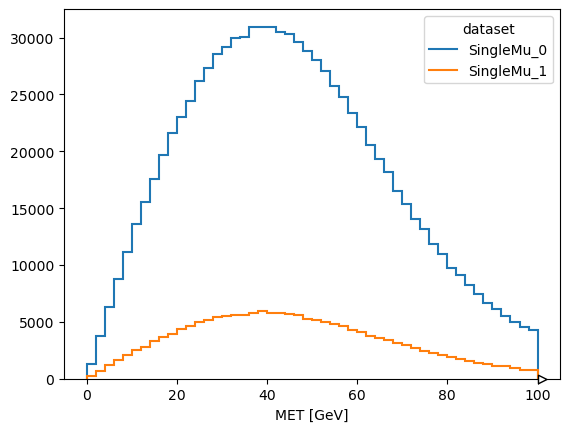

In [1]:
from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, run, CustomArtifact
from coffea_workflow import facilities
from coffea_workflow.facilities import CoffeaCasaFactory
from analysis import get_fileset, run_analysis, plot_results, custom_function_remove_last_file

step_fileset = Step(
    name="Fileset",
    step_type=Fileset,
    builder=get_fileset,
    builder_params={"to_print": "\nTEST:\npass parameter to builder...\nSUCCESS!\n"}
)

step_custom_filtering = Step(
    name="FilesetFiltering",
    step_type=CustomArtifact,
    builder=custom_function_remove_last_file,
)

step_analysis = Step(
    name="SingleMuonAnalysis",
    step_type=Analysis,
    builder=run_analysis,
)

step_plotting = Step(
    name="PlottingMuonAnalysis",
    step_type=Plotting,
    builder="analysis:plot_results"
)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

# # local, FuturesExecutor
# config = RunConfig(
#     strategy="by_dataset",
#     percentage=10,
#     chunk_fraction=0.4,
#     facility=facilities.local,
#     executor_config=ExecutorConfig(executor_type="FuturesExecutor"),
# )


# # # coffea-casa, FuturesExecutor
# config = RunConfig(
#     strategy="by_dataset",
#     percentage=10,
#     chunk_fraction=0.4,
#     facility=facilities.coffea_casa,
#     executor_config=ExecutorConfig(executor_type="FuturesExecutor"),
# )

# coffea-casa, DaskExecutor (connects to tls://localhost:8786)
config = RunConfig(
    strategy="by_dataset",
    percentage=10,
    chunk_fraction=0.7,
    facility=CoffeaCasaFactory(),
    executor_config=ExecutorConfig(
        executor_type="DaskExecutor",
        worker_packages=("git+https://github.com/hooloobooroodkoo/coffea.git@master",),
        worker_files=("analysis.py",),
    ),
)

result = run(workflow, config)
